# Nubiral - Transbank IVR/AI model

## **Objetivo**
Modelo para predicción de colas según el mensaje del usuario obtenido a través del AST de *Amazon Lex*.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install openpyxl
%pip install pandarallel

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.
  Using cached pandarallel-1.6.5-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import boto3
import json
import re
import os
from tqdm import tqdm  

tqdm.pandas()

## Data Loading

In [4]:
FILENAME = "KB2000_test_audio_inferido_ofuscado.xlsm"

df_generalizado = pd.read_excel(FILENAME)
df_generalizado.sample(5)
df_generalizado = df_generalizado.fillna("")
# df_generalizado = pd.read_excel("KB1000_V1_Total.xlsx")
# df_generalizado = df_generalizado[['Etiqueta','Necesidad_Generalizada','Problema_Generalizado']]
# df_generalizado.rename(
#     columns={
#         "Necesidad_Generalizada": "Intencion",
#         "Problema_Generalizado": "Problema",
#     },
#     inplace=True,
# )

df_generalizado["full_text"] = df_generalizado.apply(
    lambda row: "Intención: "
    + str(row["Intencion"])
    + "\n"
    + "Problema: "
    + str(row["Problema"]),
    axis=1,
)


In [6]:
df_generalizado

,etiqueta,Intencion,Problema,full_text
0,ASISTENCIA_COMERCIAL,"Tengo un problema con mi dispositivo móvil, ya...",Un dispositivo utilizado para el trabajo se bl...,Intención: Tengo un problema con mi dispositiv...
1,ASISTENCIA_COMERCIAL,Necesito el número de contacto para hacer una ...,El servicio o producto adquirido no cumplió co...,Intención: Necesito el número de contacto para...
2,ASISTENCIA_COMERCIAL,Necesito realizar una actualización de datos p...,No puedo ingresar un código en la plataforma e...,Intención: Necesito realizar una actualización...
3,ASISTENCIA_COMERCIAL,Necesito cambiar la configuración predetermina...,Un componente o función del producto no está f...,Intención: Necesito cambiar la configuración p...
4,ASISTENCIA_COMERCIAL,Estoy recibiendo información sobre una deuda p...,Estoy recibiendo información sobre una deuda p...,Intención: Estoy recibiendo información sobre ...
...,...,...,...,...
144,RETENCIONES,Necesito cancelar un servicio o producto contr...,No tengo los documentos necesarios,Intención: Necesito cancelar un servicio o pro...
145,RETENCIONES,Necesito cancelar un servicio y que se retiren...,,Intención: Necesito cancelar un servicio y que...
146,RETENCIONES,Solicitar la cancelación de un servicio,"El equipo es antiguo y lento, el servicio es d...",Intención: Solicitar la cancelación de un serv...
147,RETENCIONES,Necesito cancelar un servicio contratado.,Tengo problemas con la funcionalidad de un dis...,Intención: Necesito cancelar un servicio contr...


# Solutions

In [7]:
TEST_SIZE = 0.25
RANDOM_STATE = 42

In [8]:
from sklearn.model_selection import train_test_split

# Dividir en entrenamiento y prueba (por ejemplo, 80% entrenamiento, 20% prueba)
train_df, test_df = train_test_split(
    df_generalizado, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_generalizado["etiqueta"]
)

### Little EDA

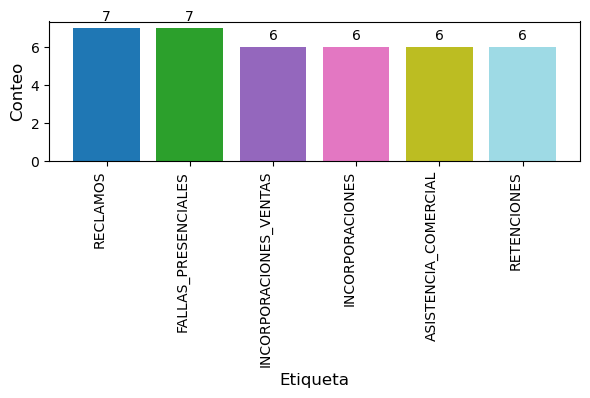

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que test_df ya está definido
counts = test_df.etiqueta.value_counts()

# Utilizar la paleta de colores de Tableau (tab20) con una cantidad de colores igual al número de barras
colores = plt.get_cmap("tab20")(np.linspace(0, 1, len(counts)))

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(counts.index, counts.values, color=colores)

# Configurar etiquetas de los ejes sin título
ax.set_xlabel("Etiqueta", fontsize=12)
ax.set_ylabel("Conteo", fontsize=12)

# Rotar etiquetas del eje x para mayor legibilidad
plt.xticks(rotation=90, ha="right", fontsize=10)

# Agregar etiquetas de valor sobre cada barra
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{int(altura)}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  # separación vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Synthetic Data

In [10]:
from src.bedrock_models_v2 import ModelConfig, LLMClient

In [11]:
sonnet37 = LLMClient(ModelConfig.CLAUDE_3_7_SONNET_SYNTHETIC.value)

In [12]:
import re

def extract_json(text):
    """
    Extrae el contenido JSON de un bloque de código formateado como:
    
    ```json
    { ... }
    ```
    
    Args:
        text (str): El texto que contiene el bloque de código.
    
    Returns:
        str or None: El string con el contenido JSON si se encontró, de lo contrario None.
    """
    pattern = r"```json\s*(\{(?:.|\s)*?\})\s*```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1)
    return None

In [13]:
SYNTHETIC_DATA_PROMPT = """ 
Genera un nuevo ejemplo de datos sintéticos para un sistema de IVR, siguiendo la misma estructura y componentes que los ejemplos proporcionados. 
El ejemplo debe ser realista, incluir una variedad de intenciones (ej. consultas, reclamos, soporte técnico). 

**Instrucciones específicas:**
1. **Texto del usuario:** Debe ser una frase coloquial que un cliente diría en un IVR.
2. **Intención:** Clasificación clara y específica (ej. "consultar_saldo", "reportar_pago").
3. **Variación:** No repitas palabras clave exactas de los ejemplos, pero mantén la lógica del escenario.

**Ejemplos proporcionados: (texto completo)**
{samples}

**Etiqueta esperada**:
{category}

**Salida esperada:**
```json
{{
    "full_text": "Hola, tengo un problema con el pos",
    "etiqueta": "RECLAMOS"
}}
```

**Requisitos adicionales:**
- La respuesta **debe ser** un JSON válido y cumplir estrictamente con el formato mostrado.
- La respuesta **debe estar** formateada en un bloque de código (usando triple backticks y especificando "json").
- No incluyas ningún comentario, explicación o texto adicional fuera del bloque de código.
- **Importante:** Asegúrate de que la propiedad `"etiqueta"` en la respuesta contenga siempre el mismo valor que se especifica en **Etiqueta esperada**.

**Nuevo ejemplo:**
"""

In [14]:
import json
import pandas as pd
from tqdm import tqdm
import time

synthetic_samples = []
max_retries = 3  # Número máximo de reintentos

# Obtenemos las etiquetas únicas
etiquetas = train_df["etiqueta"].unique()
N_SAMPLES = 5

for etiqueta in tqdm(etiquetas, desc="Etiquetas"):
    # Selecciona todos los ejemplos para la etiqueta actual y formatea la cadena de muestras
    muestras_df = train_df.loc[train_df["etiqueta"] == etiqueta, ["full_text", "etiqueta"]]
    samples_str = "\n".join(
        muestras_df.full_text.tolist()
    )
    
    # Genera N_SAMPLES sintéticos para la etiqueta actual
    for i in tqdm(range(N_SAMPLES), desc=f"Ejemplos para '{etiqueta}'", leave=False):
        retries = 0
        success = False
        while not success and retries < max_retries:
            try:
                # Ahora se pasa la categoría actual en lugar de la lista completa
                response = sonnet37.chat(SYNTHETIC_DATA_PROMPT.format(samples=samples_str, category=etiqueta))
                json_str = extract_json(response)
                synthetic_sample = json.loads(json_str)
                synthetic_samples.append(synthetic_sample)
                success = True
            except Exception as e:
                retries += 1
                print(f"Error: {e}. Reintentando ({retries}/{max_retries})...")
                time.sleep(1)  # Pequeña pausa antes de reintentar
        if not success:
            print(f"Falló después de {max_retries} reintentos para la etiqueta '{etiqueta}', muestra {i}.")

# Creamos el DataFrame con los ejemplos sintéticos generados
synthetic_df = pd.DataFrame(synthetic_samples)

Etiquetas:   0%|          | 0/6 [00:07<?, ?it/s]                          

KeyboardInterrupt



In [22]:
synthetic_df

,full_text,etiqueta
0,"Mire, quiero darme de baja del servicio de ter...",RETENCIONES
1,Me gustaría dar de baja el terminal de pagos q...,RETENCIONES
2,Necesito solicitar la baja de mi terminal punt...,RETENCIONES
3,"Mire, necesito terminar mi contrato porque me ...",RETENCIONES
4,Me gustaría cancelar mi terminal de pago porqu...,RETENCIONES
5,Quisiera verificar cuánto me queda disponible ...,ASISTENCIA_COMERCIAL
6,"Buenas tardes, llamo porque mi factura de este...",ASISTENCIA_COMERCIAL
7,Quiero verificar si mi factura electrónica del...,ASISTENCIA_COMERCIAL
8,"Buenas tardes, llamo porque no me llegó la fac...",ASISTENCIA_COMERCIAL
9,Quisiera verificar si mi pago mensual ya fue r...,ASISTENCIA_COMERCIAL


In [23]:
train_df = pd.concat([train_df, synthetic_df]).reset_index(drop=True)

In [24]:
train_df.etiqueta.value_counts()

etiqueta
RETENCIONES               24
INCORPORACIONES_VENTAS    24
INCORPORACIONES           24
ASISTENCIA_COMERCIAL      23
RECLAMOS                  23
FALLAS_PRESENCIALES       23
Name: count, dtype: int64

## **ML Classic Methods**

### *TF-IDF (Baseline)*

In [25]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# --- División del dataset ---
# Variables para entrenamiento y prueba
X_train = train_df['full_text']
y_train = train_df['etiqueta']
X_test = test_df['full_text']
y_test = test_df['etiqueta']

# --- Pipeline: TF-IDF + Regresión Logística ---
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train, y_train)

# --- Predicciones y almacenamiento en df_generalizado ---
y_pred = pipeline.predict(X_test)

# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Crear una Serie de predicciones con el índice de test_df
df_generalizado.loc[test_df.index, "y_pred_tf-idf"] = y_pred

Accuracy: 0.631578947368421
Classification Report:
                         precision    recall  f1-score   support

  ASISTENCIA_COMERCIAL       0.50      0.17      0.25         6
   FALLAS_PRESENCIALES       0.75      0.86      0.80         7
       INCORPORACIONES       0.40      0.33      0.36         6
INCORPORACIONES_VENTAS       0.50      0.33      0.40         6
              RECLAMOS       0.54      1.00      0.70         7
           RETENCIONES       1.00      1.00      1.00         6

              accuracy                           0.63        38
             macro avg       0.61      0.62      0.59        38
          weighted avg       0.62      0.63      0.59        38



### Embeddings

In [26]:
from src.embeddings import generate_cohere_embeddings, generate_titan_embeddings

In [27]:
df_generalizado["cohere_embeddings"] = df_generalizado.full_text.progress_apply(generate_cohere_embeddings)

100%|██████████| 149/149 [00:17<00:00,  8.30it/s]


In [28]:
df_generalizado["titan_embeddings"] = df_generalizado.full_text.progress_apply(generate_titan_embeddings)

100%|██████████| 149/149 [00:16<00:00,  9.13it/s]


#### *Titan Embeddings*

In [29]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


MAX_ITER = 1000

# Convertir los embeddings (listas de 1024 números) en una matriz NumPy de forma (n_samples, 1024)
X = np.vstack(df_generalizado["titan_embeddings"].values)

# Suponiendo que la columna 'etiqueta' es la etiqueta
y = df_generalizado["etiqueta"]

# Dividir en entrenamiento y prueba (por ejemplo, 80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_generalizado.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Entrenar un modelo de Regresión Logística
clf = LogisticRegression(max_iter=MAX_ITER)
clf.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Retornar predicciones a df_generalizado
df_generalizado.loc[idx_test, "y_pred_titan_embeddings"] = y_pred

Accuracy: 0.6578947368421053
Classification Report:
                         precision    recall  f1-score   support

  ASISTENCIA_COMERCIAL       0.50      0.17      0.25         6
   FALLAS_PRESENCIALES       0.83      0.71      0.77         7
       INCORPORACIONES       0.50      0.83      0.62         6
INCORPORACIONES_VENTAS       1.00      0.33      0.50         6
              RECLAMOS       0.75      0.86      0.80         7
           RETENCIONES       0.60      1.00      0.75         6

              accuracy                           0.66        38
             macro avg       0.70      0.65      0.62        38
          weighted avg       0.70      0.66      0.62        38



#### *Cohere Embeddings*

In [30]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

MAX_ITER = 1000

# Convertir los embeddings (listas de 1024 números) en una matriz NumPy de forma (n_samples, 1024)
X = np.vstack(df_generalizado["cohere_embeddings"].values)

# Suponiendo que la columna 'etiqueta' es la etiqueta
y = df_generalizado["etiqueta"]

# Dividir en entrenamiento y prueba (por ejemplo, 80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_generalizado.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Entrenar un modelo de Regresión Logística
clf = LogisticRegression(max_iter=MAX_ITER)
clf.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Retornar predicciones a df_generalizado
df_generalizado.loc[idx_test, "y_pred_cohere_embeddings"] = y_pred

Accuracy: 0.5526315789473685
Classification Report:
                         precision    recall  f1-score   support

  ASISTENCIA_COMERCIAL       0.25      0.17      0.20         6
   FALLAS_PRESENCIALES       0.80      0.57      0.67         7
       INCORPORACIONES       0.20      0.17      0.18         6
INCORPORACIONES_VENTAS       0.40      0.33      0.36         6
              RECLAMOS       0.78      1.00      0.88         7
           RETENCIONES       0.60      1.00      0.75         6

              accuracy                           0.55        38
             macro avg       0.50      0.54      0.51        38
          weighted avg       0.52      0.55      0.52        38



## **Gen-AI Methods**

### Transbank Approach

In [50]:
kb = "\n".join((train_df["etiqueta"] + " [Categoria] --> " + train_df["full_text"]).tolist())

In [51]:
import boto3
import json
import logging
from src.bedrock_models_v2 import ModelConfig, LLMClient

SYSTEM_MESSAGE = "Eres un asistente experto en clasificación de la intención de los clientes."

# Construir el prompt para la inferencia, incluyendo las etiquetas posibles
PROMPT_TEXT = """
**Intención y problema del cliente:** 
{user_input}

**Knowledge base**:
{kb}

<etiquetas>
ASISTENCIA_COMERCIAL
RECLAMOS
FALLAS_PRESENCIALES
RETENCIONES
</etiquetas>

### **Tarea**

Analiza la intención del cliente en {{user_input}} y clasifícala EXCLUSIVAMENTE con UNA de las etiquetas proporcionadas.  
No agregues ninguna otra palabra, explicación, puntuación o carácter. 
SOLO debes devolver la ETIQUETA (en mayúsculas) que mejor represente la intención del cliente.
Cualquier respuesta que contenga más de una palabra será considerada incorrecta.

**Etiqueta:**
"""

# Inicializar el logger (opcional, para ver mensajes de depuración)
logging.basicConfig(level=logging.INFO)

def infer_intention_transbank_sonnet35(user_input: str) -> str:
    try:
        # Elegir el modelo a utilizar
        model_config = ModelConfig.CLAUDE_3_5_SONNET.value  # Puedes cambiar por otro modelo
        
        # Inicializar la instancia de LLMClient con el modelo seleccionado
        llm_client = LLMClient(model_config)

        # Invocar el modelo utilizando el método chat (para obtener solo el texto de la respuesta)
        response = llm_client.chat(
            prompt=PROMPT_TEXT.format(user_input=user_input, kb=kb),
            system_prompt=SYSTEM_MESSAGE,
            temperature=0,
            max_tokens=100,
            enable_reasoning=False
        )
        
        # Imprimir la respuesta generada por el modelo
        return response
    except Exception as e:
        return f"Error en Bedrock IA: {str(e)}"

def infer_intention_transbank_sonnet37(user_input: str) -> str:
    try:
        # Elegir el modelo a utilizar
        model_config = ModelConfig.CLAUDE_3_7_SONNET.value  # Puedes cambiar por otro modelo
        
        # Inicializar la instancia de LLMClient con el modelo seleccionado
        llm_client = LLMClient(model_config)

        # Invocar el modelo utilizando el método chat (para obtener solo el texto de la respuesta)
        response = llm_client.chat(
            prompt=PROMPT_TEXT.format(user_input=user_input, kb=kb),
            system_prompt=SYSTEM_MESSAGE,
            temperature=0,
            max_tokens=100,
            enable_reasoning=False
        )
        
        # Imprimir la respuesta generada por el modelo
        return response
    except Exception as e:
        return f"Error en Bedrock IA: {str(e)}"

In [52]:
test_df["y_pred_transbank_sonnet35"] = test_df.full_text.progress_apply(lambda x: infer_intention_transbank_sonnet35(x))

  5%|▌         | 2/38 [00:03<01:11,  1.98s/it]


KeyboardInterrupt: 

In [18]:
test_df["y_pred_transbank_sonnet37"] = test_df.full_text.progress_apply(lambda x: infer_intention_transbank_sonnet37(x))

100%|██████████| 38/38 [00:59<00:00,  1.56s/it]


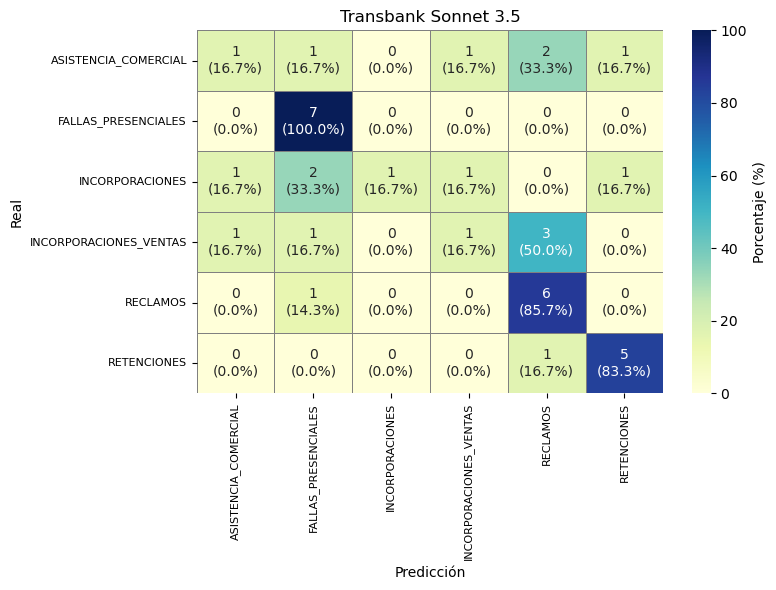

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.333333  0.166667  0.222222   6.000000
FALLAS_PRESENCIALES      0.583333  1.000000  0.736842   7.000000
INCORPORACIONES          1.000000  0.166667  0.285714   6.000000
INCORPORACIONES_VENTAS   0.333333  0.166667  0.222222   6.000000
RECLAMOS                 0.500000  0.857143  0.631579   7.000000
RETENCIONES              0.714286  0.833333  0.769231   6.000000
accuracy                 0.552632  0.552632  0.552632   0.552632
macro avg                0.577381  0.531746  0.477968  38.000000
weighted avg             0.575501  0.552632  0.488823  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.552632
1  Precision  0.575501
2     Recall  0.552632
3   F1-Score  0.488823


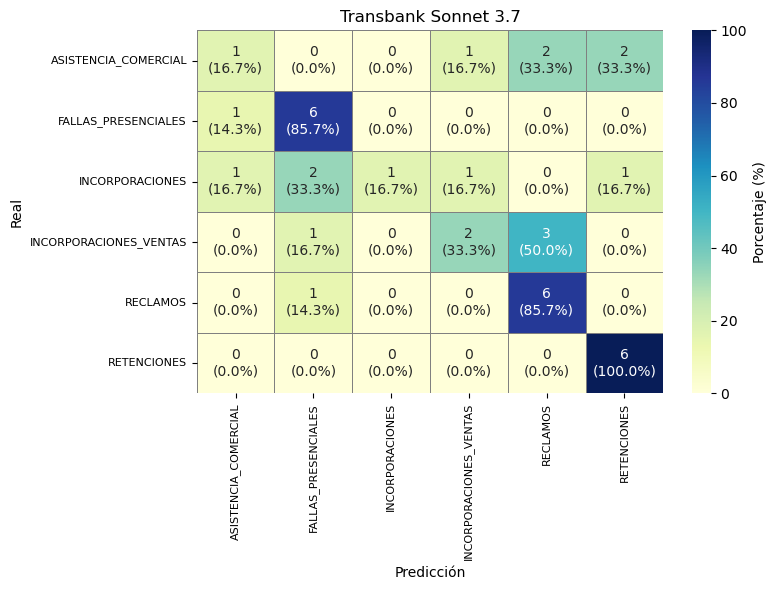

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.333333  0.166667  0.222222   6.000000
FALLAS_PRESENCIALES      0.600000  0.857143  0.705882   7.000000
INCORPORACIONES          1.000000  0.166667  0.285714   6.000000
INCORPORACIONES_VENTAS   0.500000  0.333333  0.400000   6.000000
RECLAMOS                 0.545455  0.857143  0.666667   7.000000
RETENCIONES              0.666667  1.000000  0.800000   6.000000
accuracy                 0.578947  0.578947  0.578947   0.578947
macro avg                0.607576  0.563492  0.513414  38.000000
weighted avg             0.605742  0.578947  0.522512  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.578947
1  Precision  0.605742
2     Recall  0.578947
3   F1-Score  0.522512


In [19]:
from src.viz import plot_confusion_matrix_and_report

# Evaluar el modelo
plot_confusion_matrix_and_report(test_df, "y_pred_transbank_sonnet35", "Transbank Sonnet 3.5")
plot_confusion_matrix_and_report(test_df, "y_pred_transbank_sonnet37", "Transbank Sonnet 3.7")

### Nubiral approach

In [31]:
from rich import print
from rich.panel import Panel
from rich.pretty import pprint

In [32]:
all_categories_info = train_df.groupby("etiqueta")["full_text"].apply(lambda x: " ".join(x)).to_dict()

for key, value in all_categories_info.items():
    panel = Panel(value, title=key, expand=False)
    print(panel)

╭───────────────────────────────────────────── ASISTENCIA_COMERCIAL ──────────────────────────────────────────────╮
│ Intención: Necesito realizar un proceso de pago en línea                                                        │
│ Problema: Tengo problemas para acceder al portal de clientes en línea. Intención: <salida_1Necesitamos          │
│ habilitar un método de pago en línea para que nuestros estudiantes puedan pagar por nuestros servicios de       │
│ capacitación a distancia. Este método de pago debe aceptar pagos en dólares para atender a nuestros estudiantes │
│ de diferentes países.</salida_1\n\n<salida_2Estamos buscando implementar una solución de pago en línea que      │
│ permita a nuestros clientes realizar pagos por nuestros servicios. Esta solución debe ser compatible con        │
│ múltiples monedas para satisfacer las necesidades de nuestros clientes                                          │
│ internacionales.</salida_2\n\n<salida_3Requerimos una plataforma de pago en línea que acepte diferentes         │
│ divisas, ya que ofrecemos servicios a clientes de diversos países. Esta plataforma facilitaría el proceso de    │
│ pago para nuestros clientes y mejoraría su experiencia general.</salida_3                                       │
│ Problema: El servicio o producto adquirido no cumplió con las expectativas del cliente en ciertos aspectos.     │
│ Intención: Solicité la eliminación de un servicio a través de un sistema automatizado, pero posteriormente      │
│ recibí una notificación sobre una actualización de parámetros en el punto de venta relacionado con ese          │
│ servicio.                                                                                                       │
│ Problema: Un cliente realizó una solicitud relacionada con un servicio, pero recibió una notificación           │
│ inesperada sobre una gestión diferente a la solicitada, lo que generó confusión. Intención: No puedo acceder a  │
│ una aplicación porque olvidé la contraseña.                                                                     │
│ Problema: Tengo problemas para acceder a mi cuenta debido a un error con la recuperación de contraseña o la     │
│ asociación de mi dirección de correo electrónico. Intención: Necesito cambiar la configuración predeterminada   │
│ de un dispositivo que adquirí.                                                                                  │
│ Problema: Un componente o función del producto no está funcionando correctamente. Intención: Estaba intentando  │
│ cambiar una imagen en un sitio web, pero no fue posible a pesar de seguir las instrucciones proporcionadas      │
│ sobre el formato de la imagen y acceder a las secciones correspondientes. El sistema no permitía guardar los    │
│ cambios.                                                                                                        │
│ Problema: Hay problemas para cargar o guardar imágenes en un perfil de una página web. Intención: Tengo un      │
│ problema con mi dispositivo móvil, ya que se bloqueó después de usarlo ocasionalmente. Aparece un mensaje que   │
│ indica que la cuenta está bloqueada debido a múltiples intentos fallidos de ingresar la contraseña correcta.    │
│ Problema: Un dispositivo utilizado para el trabajo se bloqueó y no se puede acceder con la contraseña           │
│ configurada. Intención: Estamos esperando un pago pendiente por parte de la empresa                             │
│ Problema: Después de contratar un servicio y abrir una cuenta, el cliente se percató de que no estaba           │
│ recibiendo los fondos esperados debido a un error en los datos de la cuenta. Intención: El sistema está         │
│ aplicando un impuesto incorrecto para el tipo de servicio que se ofrece.                                        │
│ Problema: El sistema está aplicando un cargo incorrecto. Intención: Tengo varias máquinas en diferentes         │
│ ubicaciones. Necesito cambiar la dirección registrada 

╭────────────────────────────────────────────── FALLAS_PRESENCIALES ──────────────────────────────────────────────╮
│ Intención: El sistema de transacciones presenta errores de comunicación en algunos momentos.                    │
│ Problema: El sistema presenta un error de comunicación después de ingresar las credenciales de acceso           │
│ correctamente. El problema ocurre en un momento específico del proceso, a pesar de que los pasos previos se     │
│ realizan sin inconvenientes.</salida_genérica Intención: No he podido utilizar el dispositivo debido a un error │
│ de comunicación.                                                                                                │
│ Problema: No he podido utilizar el dispositivo debido a un error de comunicación. Intención: El sistema de      │
│ procesamiento de pagos con tarjetas presenta fallas intermitentes.                                              │
│ Problema: Había un problema de comunicación entre los dispositivos. Se solicitó volver a intentar la conexión.  │
│ Se revisó la señal de los dispositivos, uno tenía una señal adecuada y el otro estaba conectado directamente al │
│ cable de red. Intención: Necesito reimprimir un comprobante de una transacción realizada.                       │
│ Problema: El sistema presentó problemas técnicos que impidieron su correcto funcionamiento en determinadas      │
│ circunstancias. Intención: El cliente solicitó un servicio pero no ha recibido respuesta ni seguimiento sobre   │
│ su solicitud.                                                                                                   │
│ Problema: Un dispositivo no está funcionando correctamente, alcanza ciertos niveles de progreso pero no logra   │
│ completar su proceso. Intención: El sistema de pago presenta fallas de conexión a Internet en ciertos momentos. │
│ Problema: El sistema de pago en línea presenta fallas intermitentes que impiden realizar compras. Intención:    │
│ Quería reportar un problema con un servicio o producto.                                                         │
│ Problema: Un dispositivo electrónico emite sonidos continuos de forma inesperada, como si se estuvieran         │
│ presionando teclas o botones, a pesar de que nadie lo está manipulando. Intención: El dispositivo presenta      │
│ problemas con la duración de la batería después de cargarla.                                                    │
│ Problema: El dispositivo de carga no funciona correctamente, parece que la capacidad de carga es insuficiente.  │
│ Intención: Tengo problemas con el sistema de pago o transacciones en línea. El proceso falla y muestra errores  │
│ de comunicación, incluso después de reiniciar.                                                                  │
│ Problema: Tengo problemas con el sistema de procesamiento de transacciones. Cada vez que intento realizar una   │
│ transacción, se produce un error de comunicación. Intención: Al realizar una transacción con tarjeta, se        │
│ presentan errores de conexión.                                                                                  │
│ Problema: Al realizar un pago con tarjeta, se presentan errores de conexión. Intención: El dispositivo no está  │
│ emitiendo el comprobante de manera correcta, el comprobante se genera sin el código de verificación requerido.  │
│ Problema: Un dispositivo no imprime correctamente un documento con un código de respuesta rápida. Intención:    │
│ Necesito ayuda con el equipo de procesamiento de pagos.                                                         │
│ Problema: El servicio de un equipo está presentando problemas. Intención: El dispositivo presenta problemas de  │
│ conexión al intentar realizar una transacción.                                                                  │
│ Problema: El dispositivo no funciona correctamente. Presenta problemas para leer la tarjeta y muestra mensajes  │
│ de error. Intención: Se necesita asistencia técnica de

╭──────────────────────────────────────────────── INCORPORACIONES ────────────────────────────────────────────────╮
│ Intención: Consulta sobre las comisiones o cargos aplicados.                                                    │
│ Problema: El sitio web presenta problemas de funcionamiento y la simulación de cálculos no se realiza           │
│ correctamente. Intención: Validar el desempeño de un representante de servicio al cliente.                      │
│ Problema: El producto o servicio no cumplió con las expectativas del cliente en algunos aspectos. Intención: No │
│ recibí el producto que compré.                                                                                  │
│ Problema: No recibí el producto que adquirí a través del servicio de compras. Intención: Necesito un método de  │
│ pago en línea para servicios, sin tener que utilizar máquinas o botones físicos.                                │
│ Problema: El servicio o producto adquirido no cumplió con las expectativas del cliente en ciertos aspectos.     │
│ Intención: Tengo una duda sobre el personal externo que realiza tareas de mantenimiento o validación de los     │
│ sistemas de pago.                                                                                               │
│ Problema: El dispositivo para emitir comprobantes es lento y poco eficiente en comparación con otros            │
│ dispositivos similares en el mercado. El proceso de impresión toma demasiado tiempo y no es fluido. Intención:  │
│ Tuve una mala experiencia al realizar una compra, ya que el dispositivo de pago parecía estar manipulado de     │
│ manera indebida, impidiendo la visualización de la pantalla. El encargado del dispositivo reaccionó de forma    │
│ agresiva cuando solicité ver la pantalla.                                                                       │
│ Problema: El personal que maneja un dispositivo no permite ver la pantalla y se comporta de manera agresiva     │
│ cuando se solicita. Intención: Necesitar validar información de identificación personal                         │
│ Problema: El servicio de internet está fallando constantemente y no puedo trabajar desde casa. Intención: Un    │
│ representante de una empresa vino y quiero validar su identidad.                                                │
│ Problema: El producto o servicio no cumplió con las expectativas del cliente en determinadas circunstancias.    │
│ Intención: Consulta sobre cargos o cobros relacionados con una transacción comercial.                           │
│ Problema: El cliente considera que el cargo es excesivamente alto. Intención: Puedo adquirir un producto o      │
│ servicio?                                                                                                       │
│ Problema: El servicio o producto adquirido no cumplió con las expectativas del cliente, generando               │
│ insatisfacción. Intención: El cliente desea obtener información sobre los precios y requisitos para adquirir un │
│ dispositivo de pago con tarjeta, con el fin de evaluar la posibilidad de comprarlo.                             │
│ Problema: El servicio o producto adquirido no cumplió con las expectativas del cliente en ciertos aspectos.     │
│ Intención: Quería conocer cómo funcionan ciertos dispositivos. Soy una persona emprendedora y voy a poner uno   │
│ de esos dispositivos en un espacio comercial.                                                                   │
│ Problema: El producto que compré no funciona correctamente. Intención: No hay suficiente información en la      │
│ transcripción para identificar la intención o problema del cliente. La transcripción solo contiene un saludo    │
│ del agente y una respuesta breve del cliente.                                                                   │
│ Problema: El servicio o producto adquirido no cumplió con las expectativas del cliente, generando una           │
│ experiencia insatisfactoria. Intención: El cliente est

╭──────────────────────────────────────────── INCORPORACIONES_VENTAS ─────────────────────────────────────────────╮
│ Intención:  Necesito saber el proceso para solicitar la desafiliación de un servicio para un negocio que ya no  │
│ lo requiere.                                                                                                    │
│ Problema: El servicio de atención al cliente no ha sido satisfactorio en algunas ocasiones. Intención: Un       │
│ cliente solicitó un producto pero no lo ha recibido                                                             │
│ Problema: No se recibió un producto solicitado Intención: El cliente quiere conocer los costos mensuales para   │
│ contratar un servicio o producto. Además, desea saber si se ofrece la opción de facturación electrónica.        │
│ Problema: Anteriormente trabajaba con un proveedor de servicios de procesamiento de pagos. Sin embargo,         │
│ experimenté problemas con cobros indebidos, como cargos duplicados, lo que me llevó a rescindir el contrato.    │
│ Ahora busco evaluar otras opciones disponibles en el mercado para determinar cuál es la más conveniente para    │
│ mis necesidades actuales. Intención: El cliente no recibió la información o acceso necesario para utilizar un   │
│ servicio o sistema, lo que le impidió realizar transacciones durante un período de tiempo. Esto generó          │
│ inconvenientes y dificultades para el cliente.                                                                  │
│ Problema: No se recibió el servicio contratado y no se pudo realizar la actividad comercial esperada.           │
│ Intención: Tengo problemas con un dispositivo o servicio tecnológico.                                           │
│ Problema: El dispositivo no proporciona el comprobante y es necesario reimprimir el registro de transacciones   │
│ recientes por cada operación. Intención: Necesitar información sobre contratar nuevos productos o servicios, o  │
│ detalles sobre suscripciones o compras existentes.                                                              │
│ Problema: El servicio o producto no cumplió con las expectativas del cliente en ciertos aspectos. Intención:    │
│ Quería contratar un servicio                                                                                    │
│ Problema: El servicio de atención al cliente no ha sido satisfactorio en algunas ocasiones. Intención: Solicité │
│ unos servicios, pero desconozco el estado actual del proceso.                                                   │
│ Problema: El producto que compré no funciona correctamente. Intención:  Solicitar información sobre productos o │
│ servicios ofrecidos                                                                                             │
│ Problema: El servicio de atención al cliente no cumplió con las expectativas del usuario en cierta ocasión.     │
│ Intención: Tengo dudas sobre las comisiones y cargos asociados con un servicio o producto ofrecido.             │
│ Problema: El producto que compré no funciona correctamente. Intención: Una empresa está buscando habilitar un   │
│ sistema de pago en línea para su sitio web de comercio electrónico y desea conocer las opciones disponibles,    │
│ los precios, la integración con el sitio web y otros detalles relacionados.                                     │
│ Problema: No se proporcionó ninguna frase para generalizar. Intención: Tengo una duda con respecto a una compra │
│ realizada y quiero verificar si se aplicaron los descuentos correspondientes de acuerdo con las condiciones de  │
│ la oferta.                                                                                                      │
│ Problema: El servicio o producto adquirido no cumplió con las expectativas del cliente. Intención: El cliente   │
│ está solicitando información sobre el estado de un trámite o proceso que ha iniciado, ya que no ha recibido     │
│ respuesta en un tiempo considerable.                  

╭─────────────────────────────────────────────────── RECLAMOS ────────────────────────────────────────────────────╮
│ Intención: Están recibiendo llamadas de cobranza por una deuda que ya fue saldada.                              │
│ Problema: Están cobrando una deuda que ya fue saldada. Intención: El cliente está experimentando demoras y      │
│ dificultades recurrentes en un proceso de gestión. A pesar de sus esfuerzos por proporcionar la documentación   │
│ requerida, siente que sus solicitudes no están siendo atendidas de manera efectiva.                             │
│ Problema: Se solicitó un servicio, pero cuando los clientes regresan, no se les proporciona la información o    │
│ documentos requeridos de manera consistente. Intención: Un producto presenta un problema de funcionamiento      │
│ durante un período prolongado y aún no se ha resuelto.                                                          │
│ Problema: El producto no funciona correctamente. Intención: Un cliente está solicitando un producto específico. │
│ Problema: No he recibido un producto que pedí y ahora no tengo existencias, por lo que tengo que conseguirlo de │
│ otras fuentes. Intención: El cliente está expresando su confusión sobre recibir rollos de una máquina de manera │
│ recurrente y desea saber el motivo de esto.                                                                     │
│ Problema:  Intención: Estoy revisando la factura que me emitieron y no coincide con las comisiones cobradas.    │
│ ¿Por qué hay una discrepancia en los cargos?                                                                    │
│ Problema: Hay inconsistencias entre los registros de un sistema y los registros oficiales. Intención: Solicitud │
│ de asistencia relacionada con un servicio o producto adquirido previamente.                                     │
│ Problema: Un producto esperado no ha llegado a su destino en el tiempo previsto. Intención: El cliente tiene    │
│ una cuenta con un proveedor de servicios de pago, con dos modalidades: máquinas de punto de venta y un sistema  │
│ de pago en línea. Algunas transacciones realizadas por los clientes no se han reflejado correctamente en la     │
│ cuenta.                                                                                                         │
│ Problema: Algunos clientes han realizado pagos, pero estos no se han reflejado en sus cuentas después de un     │
│ tiempo transcurrido. Intención: Un cliente necesita realizar una devolución o reembolso de una compra.          │
│ Problema: Estoy intentando realizar una devolución de una compra, pero he tenido dificultades para completar el │
│ proceso. Intención: Presenté un reclamo a la empresa. Me notificaron que lo habían derivado a otro              │
│ departamento, pero sin brindar detalles sobre a quién ni recibir actualizaciones posteriores sobre el estado de │
│ mi reclamo.                                                                                                     │
│ Problema: Las comisiones cobradas por un servicio están por encima del límite normativo establecido. Intención: │
│ El cliente no puede acceder a su información de solicitudes en el portal en línea.                              │
│ Problema: Tengo problemas para acceder a mi cuenta en línea y realizar un seguimiento de mis solicitudes        │
│ previas. Intención: Hice una transacción y recibí un monto menor al esperado. Hay una diferencia que no puedo   │
│ explicar.                                                                                                       │
│ Problema: Se están realizando cargos o descuentos incorrectos en mi cuenta. Intención: Quiero cambiar la        │
│ modalidad de un servicio financiero                                                                             │
│ Problema: No se están recibiendo los pagos/transferencias de manera correcta. Intención: Estoy teniendo         │
│ problemas con un servicio o producto                  

╭────────────────────────────────────────────────── RETENCIONES ──────────────────────────────────────────────────╮
│ Intención: El cliente no puede completar un trámite o proceso debido a interrupciones o falta de respuesta en   │
│ el servicio.                                                                                                    │
│ Problema: Debido a circunstancias personales, no puedo continuar con el proceso en este momento. Intención: El  │
│ cliente contrató un sistema, pero no ha tenido los resultados esperados. Solicita darlo de baja antes de que se │
│ le cobre el mantenimiento.                                                                                      │
│ Problema: El sistema de pago contratado no ha permitido realizar ventas. Intención: Necesito devolver un        │
│ servicio contratado porque voy a cambiar de ubicación.                                                          │
│ Problema:  Intención: Necesito dar de baja un servicio o producto porque ya no lo requiero más.                 │
│ Problema: El cliente no expresó un problema o inquietud específica. Intención: Quiero cancelar mi afiliación a  │
│ un servicio.                                                                                                    │
│ Problema:  Intención: Cliente quiere cancelar un servicio que tiene contratado.                                 │
│ Problema:  Intención: Necesito cancelar un servicio                                                             │
│ Problema:  Intención: Un cliente cerró un negocio e informó a la empresa de servicios correspondiente sobre el  │
│ cierre y la devolución de los productos. Sin embargo, tiempo después, la empresa contactó al cliente indicando  │
│ que aún mantiene un saldo pendiente y que su contrato no ha sido cerrado según lo solicitado.                   │
│ Problema: El cliente expresa confusión sobre el estado de un proceso de cancelación que creía haber completado. │
│ Intención: Quiero devolver un producto que recibí.                                                              │
│ Problema: No he activado un servicio o funcionalidad Intención: Tengo un dispositivo de procesamiento de pagos  │
│ y lo estoy utilizando para mis negocios. ¿Cómo puedo darlo de baja o cancelar su uso?                           │
│ Problema:  Intención: Quiero cancelar un servicio o producto contratado previamente.                            │
│ Problema: El sistema de pago no permitía realizar ciertas transacciones. Intención: Necesito devolver un        │
│ dispositivo/equipo. ¿Dónde puedo entregarlo?                                                                    │
│ Problema: Tuve problemas para acceder a un portal en línea y obtener información sobre cargos y pagos. A pesar  │
│ de múltiples intentos, no logré resolverlo y quedé sin conocer los detalles de mi situación. Intención:         │
│ Necesito cancelar un servicio o producto contratado.                                                            │
│ Problema: No tengo los documentos necesarios Intención: Quiero cancelar un servicio. ¿Cuál es el procedimiento  │
│ a seguir?                                                                                                       │
│ Problema:  Intención: Quiero presentar un reclamo o queja                                                       │
│ Problema: No se están recibiendo los pagos/depósitos en los plazos esperados. Intención: Necesito anular una    │
│ compra realizada.                                                                                               │
│ Problema: No he podido utilizar un servicio o producto, por lo que quiero solicitar uno nuevo, pero no me       │
│ permiten hacerlo debido a que ya existe una solicitud previa a mi nombre. Intención: Necesito cancelar un       │
│ servicio y que se retiren los equipos asociados                                                                 │
│ Problema:  Intención: Quieren cancelar un servicio o p

In [33]:
import src.patterns_extraction_prompt as pep
from collections import defaultdict

# Se especifica que el valor por defecto será un diccionario vacío
pep_dict = defaultdict(dict)
pep_dict["pep_original"]["prompt"] = pep.PEP_ORIGINAL
pep_dict["pep_gemini_pro_exp"]["prompt"] = pep.PEP_GEMINI_PRO_EXP 
pep_dict["pep_gemini_thinking"]["prompt"] = pep.PEP_GEMINI_THINKING 
pep_dict["pep_r1"]["prompt"] = pep.PEP_R1 
pep_dict["pep_sonnet_37"]["prompt"] = pep.PEP_SONNET_37 
pep_dict["pep_gpt"]["prompt"] = pep.PEP_GPT

TEMPERATURE = 0.0
MAX_TOKENS = 3000 
REASONING_BUDGET = 1500

for key, value in pep_dict.items():
    # Inicializamos la clave 'category_prompt' manualmente para evitar KeyError
    value["category_prompt"] = {}
    prompt = value["prompt"]

    for category, raw_text in tqdm(all_categories_info.items()):
        model_config = ModelConfig.CLAUDE_3_7_SONNET.value
        llm_client = LLMClient(model_config)

        formatted_prompt = prompt.format(categoria=category, texto_categoria=raw_text)
    
        # Invocar el modelo utilizando el método chat (para obtener solo el texto de la respuesta)
        response = llm_client.chat(
            prompt=formatted_prompt,
            temperature=0.0,
            max_tokens=MAX_TOKENS,
            reasoning_budget=REASONING_BUDGET,
            enable_reasoning=True
        )
        
        value["category_prompt"][category] = response

INFO:botocore.parsers:Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
INFO:botocore.parsers:Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
INFO:botocore.parsers:Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
INFO:botocore.parsers:Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
INFO:botocore.parsers:Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
INFO:botocore.parsers:Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
100%|██████████| 6/6 [02:36<00:00, 26.10s/it]
INFO:botocore.parsers:Received a tagged union response

In [34]:
import os
import json
from datetime import datetime

FOLDER = "generated_prompts"
# Crear la carpeta si no existe
os.makedirs(FOLDER, exist_ok=True)

# Convertir el defaultdict a un dict normal (los defaultdict no son serializables directamente)
pep_dict_normal = {key: dict(value) for key, value in pep_dict.items()}

# Obtener el timestamp actual
filename = f'{FOLDER}/pep_dict_mt-{MAX_TOKENS}_rb-{REASONING_BUDGET}.json'

# Guardar en un archivo JSON con el timestamp en el nombre
with open(filename, 'w', encoding='utf-8') as file:
    json.dump(pep_dict_normal, file, ensure_ascii=False, indent=4)

In [35]:
GENERAL_PROMPT = """
Eres un clasificador experto en atención al cliente.  Tu tarea es clasificar el siguiente texto del usuario en una de las categorías predefinidas.

Contexto General (Información de Todas las Categorías):
```
{all_context}
```

Texto del Usuario:
```
{user_text}
```

Instrucciones:

Lee cuidadosamente el contexto general y el texto del usuario.  Determina a cuál de las categorías descritas en el contexto general pertenece más probablemente el texto del usuario.

Formato de Salida (JSON):

```json
{{
  "choice": "[Nombre de la Categoría]"
}}
```
"""

In [36]:
import re

def extract_choice(text: str) -> str:
    """
    Extrae el valor asociado a "choice" dentro de un bloque JSON en el texto.

    Ejemplo:
    ```json
    {
      "choice": "ASISTENCIA_COMERCIAL"
    }
    ```
    
    Retorna: "ASISTENCIA_COMERCIAL" si se encuentra, o None en caso contrario.
    """
    pattern = r'"choice"\s*:\s*"([^"]+)"'
    match = re.search(pattern, text)
    if match:
        return match.group(1)
    return None

def run_inference_sonnet35(user_text):
    """
    Realiza la inferencia utilizando el modelo especificado y extrae el campo "choice" del resultado.
    
    Parámetros:
        row_index (int): Índice de la fila de test_df a utilizar para extraer el user_text.
    """
    # Seleccionar la configuración del modelo (puedes cambiar por otro modelo)
    model_config = ModelConfig.CLAUDE_3_5_SONNET.value
    # Inicializar la instancia de LLMClient con el modelo seleccionado
    llm_client = LLMClient(model_config)
    
    # Construir el prompt utilizando la variable GENERAL_PROMPT, all_context y el texto de test_df
    final_prompt = GENERAL_PROMPT.format(all_context=all_patterns_context, user_text=user_text)
    
    # Realizar la inferencia
    response = llm_client.chat(
        prompt=final_prompt,
        temperature=0,
        max_tokens=500,
        enable_reasoning=False
    )
    
    # Extraer el valor de "choice" usando la función extract_choice
    choice = extract_choice(response)
    return choice

def run_inference_sonnet37(user_text):
    """
    Realiza la inferencia utilizando el modelo especificado y extrae el campo "choice" del resultado.
    
    Parámetros:
        row_index (int): Índice de la fila de test_df a utilizar para extraer el user_text.
    """
    # Seleccionar la configuración del modelo (puedes cambiar por otro modelo)
    model_config = ModelConfig.CLAUDE_3_5_SONNET.value
    # Inicializar la instancia de LLMClient con el modelo seleccionado
    llm_client = LLMClient(model_config)
    
    # Construir el prompt utilizando la variable GENERAL_PROMPT, all_context y el texto de test_df
    final_prompt = GENERAL_PROMPT.format(all_context=all_patterns_context, user_text=user_text)
    
    # Realizar la inferencia
    response = llm_client.chat(
        prompt=final_prompt,
        temperature=0,
        max_tokens=500,
        enable_reasoning=False
    )
    
    # Extraer el valor de "choice" usando la función extract_choice
    choice = extract_choice(response)
    return choice

In [37]:
from tqdm import tqdm

def inference_funct(user_text):
    """
    Realiza la inferencia utilizando el modelo especificado y extrae el campo "choice" del resultado.
    
    Parámetros:
        row_index (int): Índice de la fila de test_df a utilizar para extraer el user_text.
    """
    # Seleccionar la configuración del modelo (puedes cambiar por otro modelo)
    model_config = ModelConfig.CLAUDE_3_5_SONNET.value
    # Inicializar la instancia de LLMClient con el modelo seleccionado
    llm_client = LLMClient(model_config)

    my_dict = {}

    for prompt_name, value in pep_dict.items():
        category_prompt = value["category_prompt"]

        full_category_context = ("\n\n".join([f"{k}: {v}" for k, v in category_prompt.items()]))

        # Construir el prompt utilizando la variable GENERAL_PROMPT, all_context y el texto de test_df
        final_prompt = GENERAL_PROMPT.format(all_context=full_category_context, user_text=user_text)
        
        # Realizar la inferencia
        response = llm_client.chat(
            prompt=final_prompt,
            temperature=0,
            max_tokens=600,
            enable_reasoning=False
        )
        
        # Extraer el valor de "choice" usando la función extract_choice
        choice = extract_choice(response)
        my_dict[prompt_name] = choice

    return my_dict

In [38]:
from pandarallel import pandarallel

# Inicializar pandarallel (opcionalmente, puedes configurar el número de workers)
pandarallel.initialize(nb_workers=4, progress_bar=True)

# Aplicar la función en paralelo y guardar el resultado en una nueva columna
test_df["results"] = test_df.full_text.parallel_apply(inference_funct)

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [39]:
test_df = test_df.join(test_df.results.apply(pd.Series).add_prefix("y_pred_")).drop(columns=["results"])

In [40]:
results_df = test_df

In [33]:
results_df = pd.concat([test_df, df_generalizado.dropna()[["y_pred_tf-idf", "y_pred_titan_embeddings", "y_pred_cohere_embeddings"]]], axis=1)

KeyError: "['y_pred_titan_embeddings', 'y_pred_cohere_embeddings'] not in index"

In [41]:
result_columns = results_df.filter(like="y_pred").columns

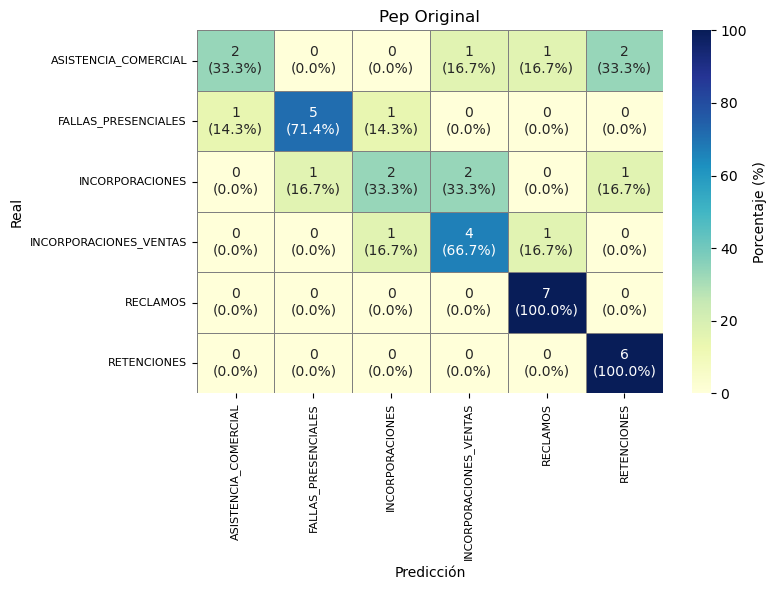

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.666667  0.333333  0.444444   6.000000
FALLAS_PRESENCIALES      0.833333  0.714286  0.769231   7.000000
INCORPORACIONES          0.500000  0.333333  0.400000   6.000000
INCORPORACIONES_VENTAS   0.571429  0.666667  0.615385   6.000000
RECLAMOS                 0.777778  1.000000  0.875000   7.000000
RETENCIONES              0.666667  1.000000  0.800000   6.000000
accuracy                 0.684211  0.684211  0.684211   0.684211
macro avg                0.669312  0.674603  0.650677  38.000000
weighted avg             0.676483  0.684211  0.659700  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.684211
1  Precision  0.676483
2     Recall  0.684211
3   F1-Score  0.659700


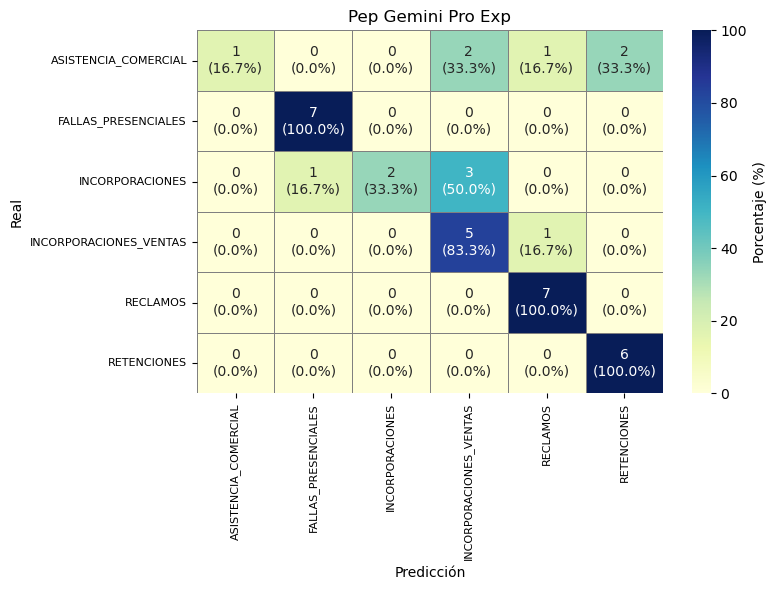

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     1.000000  0.166667  0.285714   6.000000
FALLAS_PRESENCIALES      0.875000  1.000000  0.933333   7.000000
INCORPORACIONES          1.000000  0.333333  0.500000   6.000000
INCORPORACIONES_VENTAS   0.500000  0.833333  0.625000   6.000000
RECLAMOS                 0.777778  1.000000  0.875000   7.000000
RETENCIONES              0.750000  1.000000  0.857143   6.000000
accuracy                 0.736842  0.736842  0.736842   0.736842
macro avg                0.817130  0.722222  0.679365  38.000000
weighted avg             0.817617  0.736842  0.691197  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.736842
1  Precision  0.817617
2     Recall  0.736842
3   F1-Score  0.691197


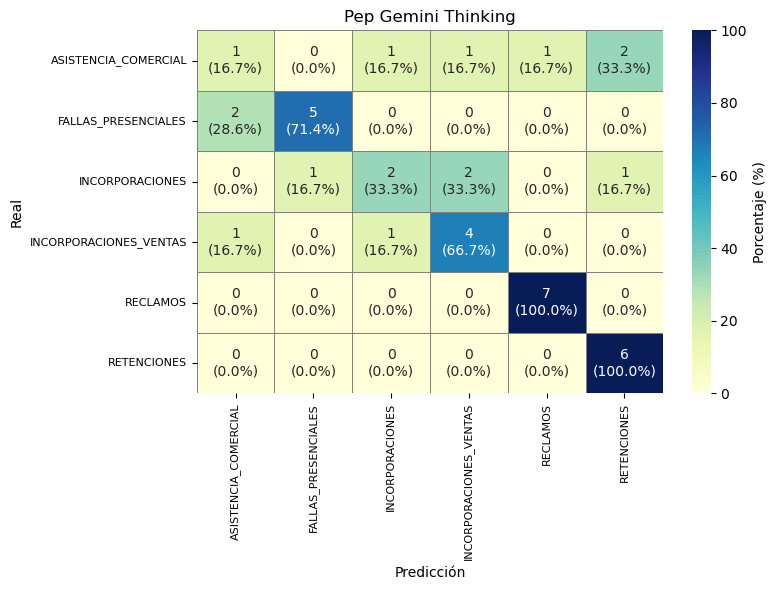

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.250000  0.166667  0.200000   6.000000
FALLAS_PRESENCIALES      0.833333  0.714286  0.769231   7.000000
INCORPORACIONES          0.500000  0.333333  0.400000   6.000000
INCORPORACIONES_VENTAS   0.571429  0.666667  0.615385   6.000000
RECLAMOS                 0.875000  1.000000  0.933333   7.000000
RETENCIONES              0.666667  1.000000  0.800000   6.000000
accuracy                 0.657895  0.657895  0.657895   0.657895
macro avg                0.616071  0.646825  0.619658  38.000000
weighted avg             0.628603  0.657895  0.631849  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.657895
1  Precision  0.628603
2     Recall  0.657895
3   F1-Score  0.631849


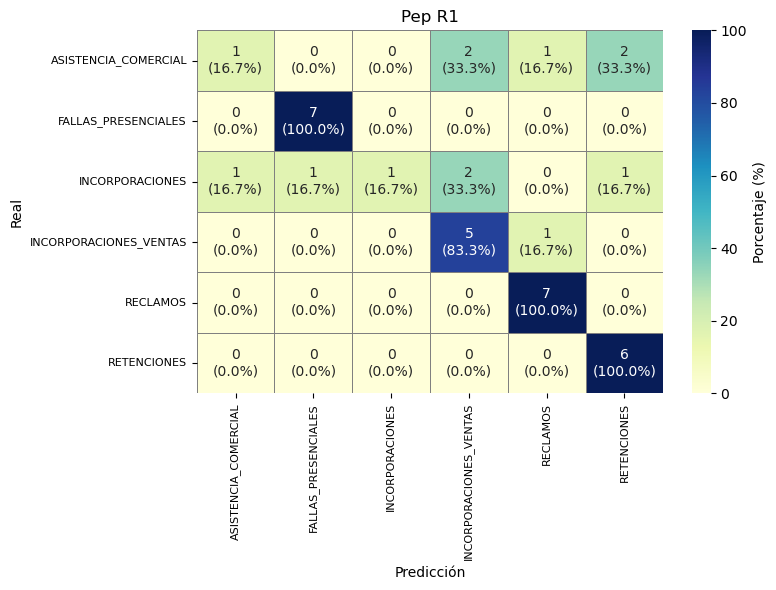

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.500000  0.166667  0.250000   6.000000
FALLAS_PRESENCIALES      0.875000  1.000000  0.933333   7.000000
INCORPORACIONES          1.000000  0.166667  0.285714   6.000000
INCORPORACIONES_VENTAS   0.555556  0.833333  0.666667   6.000000
RECLAMOS                 0.777778  1.000000  0.875000   7.000000
RETENCIONES              0.666667  1.000000  0.800000   6.000000
accuracy                 0.710526  0.710526  0.710526   0.710526
macro avg                0.729167  0.694444  0.635119  38.000000
weighted avg             0.734284  0.710526  0.649279  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.710526
1  Precision  0.734284
2     Recall  0.710526
3   F1-Score  0.649279


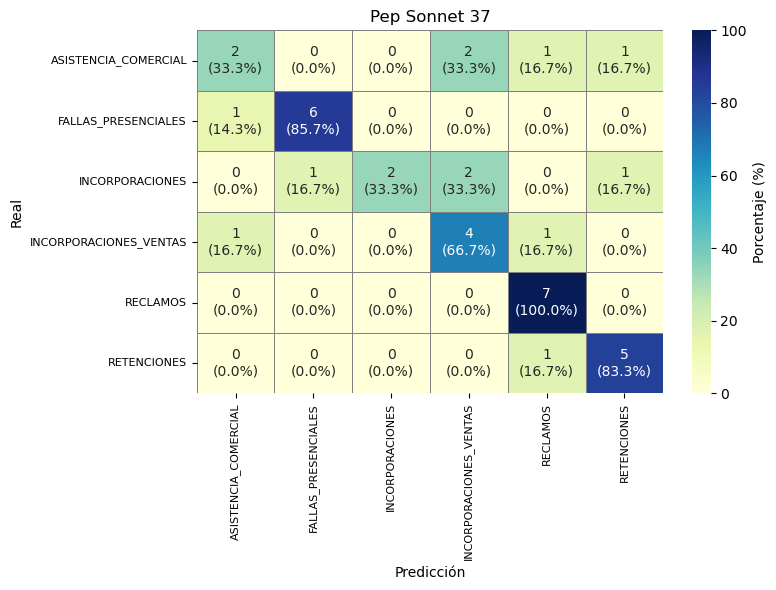

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.500000  0.333333  0.400000   6.000000
FALLAS_PRESENCIALES      0.857143  0.857143  0.857143   7.000000
INCORPORACIONES          1.000000  0.333333  0.500000   6.000000
INCORPORACIONES_VENTAS   0.500000  0.666667  0.571429   6.000000
RECLAMOS                 0.700000  1.000000  0.823529   7.000000
RETENCIONES              0.714286  0.833333  0.769231   6.000000
accuracy                 0.684211  0.684211  0.684211   0.684211
macro avg                0.711905  0.670635  0.653555  38.000000
weighted avg             0.715414  0.684211  0.663386  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.684211
1  Precision  0.715414
2     Recall  0.684211
3   F1-Score  0.663386


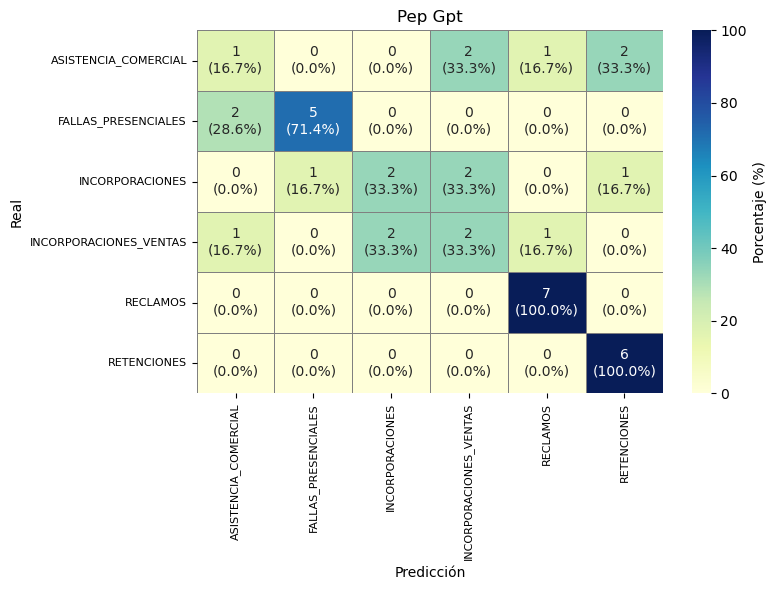

Reporte de Métricas:
                        precision    recall  f1-score    support
ASISTENCIA_COMERCIAL     0.250000  0.166667  0.200000   6.000000
FALLAS_PRESENCIALES      0.833333  0.714286  0.769231   7.000000
INCORPORACIONES          0.500000  0.333333  0.400000   6.000000
INCORPORACIONES_VENTAS   0.333333  0.333333  0.333333   6.000000
RECLAMOS                 0.777778  1.000000  0.875000   7.000000
RETENCIONES              0.666667  1.000000  0.800000   6.000000
accuracy                 0.605263  0.605263  0.605263   0.605263
macro avg                0.560185  0.591270  0.562927  38.000000
weighted avg             0.573099  0.605263  0.576569  38.000000

Métricas individuales:
     Métrica     Valor
0   Accuracy  0.605263
1  Precision  0.573099
2     Recall  0.605263
3   F1-Score  0.576569


In [42]:
from src.viz import plot_confusion_matrix_and_report

for col in result_columns:
    col_title = col.replace("y_pred_", "").replace("_", " ").title()
    plot_confusion_matrix_and_report(results_df, col, col_title)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_dict = {}

for col in result_columns:
    y_true = results_df["etiqueta"]
    y_pred = results_df[col]
    # Se calculan métricas usando el promedio "weighted" para casos multicategoría
    results_dict[col] = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='weighted'),
        "recall": recall_score(y_true, y_pred, average='weighted'),
        "f1_score": f1_score(y_true, y_pred, average='weighted')
    }

results_full_df = pd.DataFrame.from_dict(results_dict).T

In [44]:
results_full_df.index = [item.replace("y_pred_", "").replace("_", " ").title() for item in results_full_df.index]

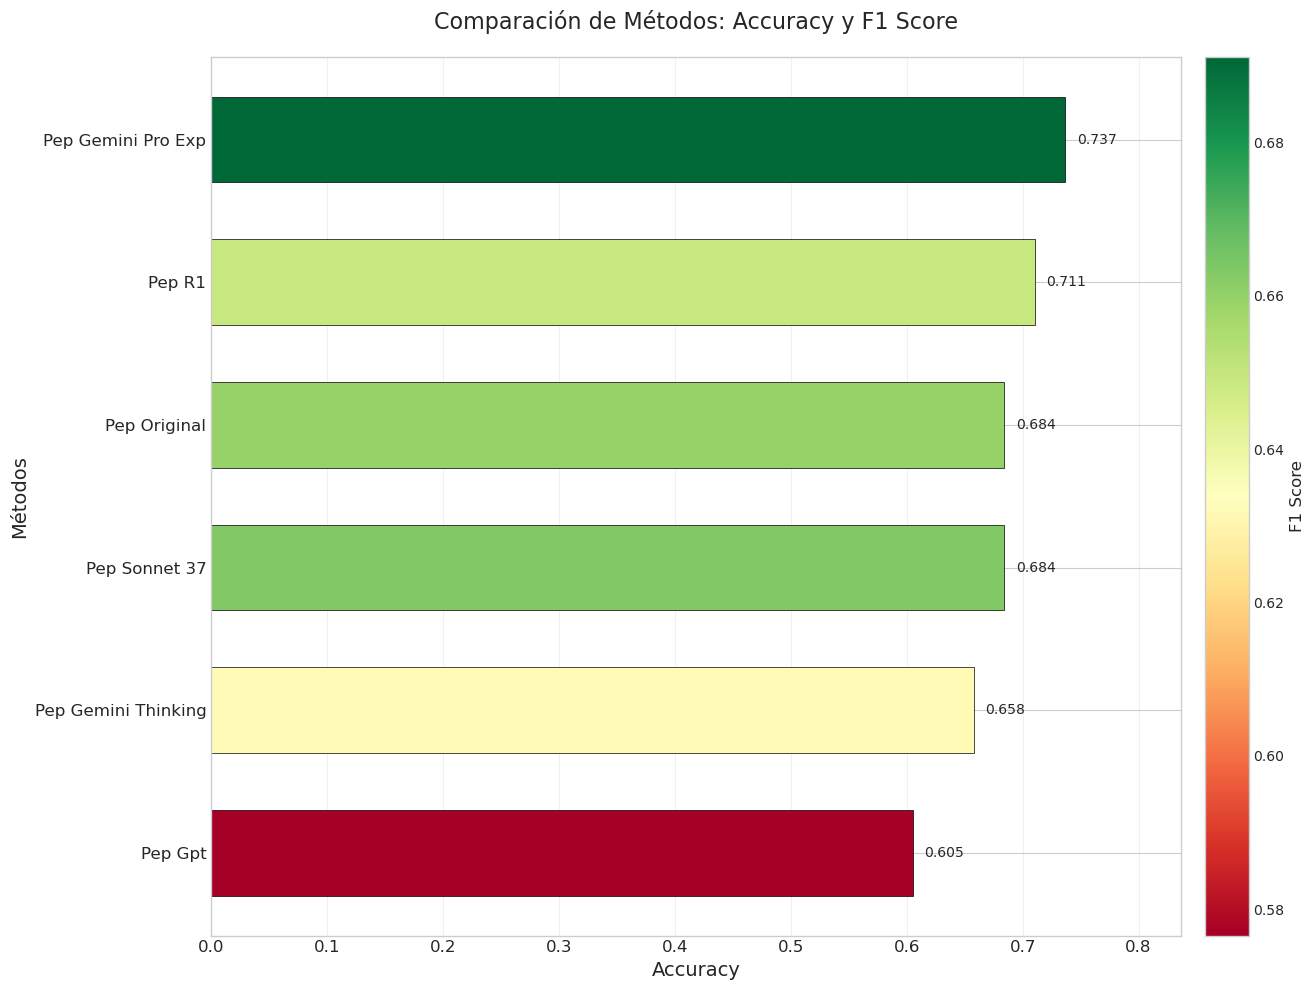

In [45]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Ordenar por accuracy para mejor visualización
results_full_df_sorted = results_full_df.sort_values(by='accuracy', ascending=True)

# Configuración de colores y normalización
cmap = plt.get_cmap("RdYlGn")
norm = mpl.colors.Normalize(vmin=results_full_df_sorted["f1_score"].min(),
                            vmax=results_full_df_sorted["f1_score"].max())
colors = [cmap(norm(val)) for val in results_full_df_sorted["f1_score"]]

# Baseline configuration
baseline_mask = results_full_df_sorted.index.str.contains("Tf-Idf")
baseline_value = results_full_df_sorted[baseline_mask]["accuracy"].values[0] if baseline_mask.any() else None

# Configurar figura
fig, ax = plt.subplots(figsize=(14, 10))

# Crear gráfico de barras con barras más delgadas (height reducido a 0.4)
bars = ax.barh(results_full_df_sorted.index, 
               results_full_df_sorted["accuracy"], 
               color=colors, 
               edgecolor='black',
               linewidth=0.5,
               height=0.6)

# Añadir línea de baseline
if baseline_value is not None:
    ax.axvline(x=baseline_value, 
               color='red', 
               linestyle='--', 
               linewidth=2,
               label='TF-IDF Baseline')
    ax.annotate(f'Baseline: {baseline_value:.2f}',
                xy=(baseline_value, 0.05),
                xycoords=('data', 'axes fraction'),
                textcoords='offset points',
                xytext=(10, 0),
                color='red',
                fontsize=12,
                arrowprops=dict(arrowstyle="->", color='red'))

# Añadir etiquetas de valor
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{width:.3f}',
            va='center',
            ha='left',
            fontsize=10)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('F1 Score', fontsize=12)

# Ajustes finales
ax.set_xlabel('Accuracy', fontsize=14)
ax.set_ylabel('Métodos', fontsize=14)
ax.set_title('Comparación de Métodos: Accuracy y F1 Score', fontsize=16, pad=20)
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(left=0, right=min(1.0, results_full_df_sorted["accuracy"].max() + 0.1))

# Grid y leyenda
ax.grid(True, axis='x', alpha=0.3)
if baseline_value is not None:
    ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()


In [29]:
import datetime
import src.patterns_extraction_prompt as pep
from src.ivr_classifier import IvrClassifier

GENERAL_PROMPT = """
Eres un clasificador experto en atención al cliente.  Tu tarea es clasificar el siguiente texto del usuario en una de las categorías predefinidas.

Contexto General (Información de Todas las Categorías):
```
{all_context}
```

Texto del Usuario:
```
{user_text}
```

Instrucciones:

Lee cuidadosamente el contexto general y el texto del usuario.  Determina a cuál de las categorías descritas en el contexto general pertenece más probablemente el texto del usuario.

Formato de Salida (JSON):

```json
{{
  "choice": "[Nombre de la Categoría]"
}}
```
"""

# Generar la fecha y hora actual en formato AAAAMMDD_HHMMSS
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
PATTERNS_OUTPUT_PATH = f"generated_prompts/patterns_results_{current_time}.json"

PEP_MODEL_CONFIG = ModelConfig.CLAUDE_3_7_SONNET.value
PEP_MODEL_CONFIG["model_params"]["reasoning_budget"] = 2400
pep_llm = LLMClient(PEP_MODEL_CONFIG)

classifier = IvrClassifier(
    pep=pep.PEP_GEMINI_PRO_EXP,
    general_prompt=GENERAL_PROMPT,
    patterns_output_path=PATTERNS_OUTPUT_PATH,
    model_config=ModelConfig.CLAUDE_3_5_SONNET.value
)

2025-03-28 18:04:14,611 - IvrClassifier - INFO - Procesamiento paralelo inicializado con 4 workers
2025-03-28 18:04:14,612 - IvrClassifier - INFO - Inicializando IvrClassifier con parámetros:
2025-03-28 18:04:14,613 - IvrClassifier - INFO -   - enable_reasoning: False
2025-03-28 18:04:14,614 - IvrClassifier - INFO -   - general_prompt: '
Eres un clasificador experto en atención al clien...'
2025-03-28 18:04:14,615 - IvrClassifier - INFO -   - max_tokens: 500
2025-03-28 18:04:14,616 - IvrClassifier - INFO -   - model_config: {'model_id': 'us.anthropic.claude-3-5-sonnet-20241022-v2:0', 'model_params': {'temperature': 0.0, 'max_tokens': 4000}}
2025-03-28 18:04:14,617 - IvrClassifier - INFO -   - n_workers: 4
2025-03-28 18:04:14,618 - IvrClassifier - INFO -   - patterns_output_path: generated_prompts/patterns_results_20250328_180414.json
2025-03-28 18:04:14,623 - IvrClassifier - INFO -   - pep: '
Eres un experto analista de texto especializado e...'
2025-03-28 18:04:14,625 - IvrClassifier 

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [30]:
# Ajustar el modelo con datos de entrenamiento
classifier.fit(train_df["full_text"], train_df["etiqueta"], pep_llm=pep_llm, force_training=True)

2025-03-28 18:04:15,794 - IvrClassifier - INFO - Iniciando proceso fit...
2025-03-28 18:04:15,798 - IvrClassifier - INFO - Extrayendo patrones usando el LLM proporcionado (`pep_llm`).
2025-03-28 18:04:15,805 - IvrClassifier - INFO - Categorías detectadas y ordenadas: ['ASISTENCIA_COMERCIAL', 'FALLAS_PRESENCIALES', 'INCORPORACIONES', 'INCORPORACIONES_VENTAS', 'RECLAMOS', 'RETENCIONES']
2025-03-28 18:04:15,811 - IvrClassifier - INFO - Extrayendo patrones para 6 categorías...
2025-03-28 18:04:47,428 - botocore.parsers - INFO - Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
2025-03-28 18:05:10,225 - botocore.parsers - INFO - Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full response support.
2025-03-28 18:05:34,492 - botocore.parsers - INFO - Received a tagged union response with member unknown to client: reasoningContent. Please upgrade SDK for full 

IvrClassifier(general_prompt='\n'
                             'Eres un clasificador experto en atención al '
                             'cliente.  Tu tarea es clasificar el siguiente '
                             'texto del usuario en una de las categorías '
                             'predefinidas.\n'
                             '\n'
                             'Contexto General (Información de Todas las '
                             'Categorías):\n'
                             '```\n'
                             '{all_context}\n'
                             '```\n'
                             '\n'
                             'Texto del Usuario:\n'
                             '```\n'
                             '{user_text}\n'
                             '```\n'
                             '\n'
                             'Instrucciones:\n'
                             '\n'
                             'Lee cuidadosame...
                  'palabras que reflejen las intenciones y problemas. Separa '
                  'las palabras clave por comas.\n'
                  '\n'
                  'Formato de Salida:\n'
                  '\n'
                  'Patrones de Intención:\n'
                  '- [Patrón de intención 1]\n'
                  '- [Patrón de intención 2]\n'
                  '- ...\n'
                  '\n'
                  'Patrones de Problema:\n'
                  '- [Patrón de problema 1]\n'
                  '- [Patrón de problema 2]\n'
                  '- ...\n'
                  '\n'
                  'Palabras Clave:\n'
                  '[palabra clave 1], [palabra clave 2], [palabra clave 3], '
                  '...\n'
                  '\n')

In [31]:
import datetime

# Generar la fecha y hora actual en formato AAAAMMDD_HHMMSS
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_PATH = f"trained_models/nubiral_classifier_model_{current_time}.pkl"

# Guardar el modelo completo
classifier.save(MODEL_PATH)

# Cargar el modelo para uso futuro
loaded_model = IvrClassifier.load(MODEL_PATH)

2025-03-28 18:07:04,165 - IvrClassifier - INFO - Modelo ajustado, procediendo a guardar.
2025-03-28 18:07:04,168 - IvrClassifier - INFO - Modelo guardado exitosamente con joblib (comprimido) en: trained_models/nubiral_classifier_model_20250328_180704.pkl
2025-03-28 18:07:04,169 - IvrClassifier - INFO - Intentando cargar modelo con joblib desde: trained_models/nubiral_classifier_model_20250328_180704.pkl
2025-03-28 18:07:04,171 - IvrClassifier - INFO - Modelo cargado exitosamente con joblib desde trained_models/nubiral_classifier_model_20250328_180704.pkl
2025-03-28 18:07:04,172 - IvrClassifier - INFO - El modelo cargado parece estar ajustado.


In [32]:
# Realizar predicciones con el modelo cargado
predictions = loaded_model.predict(test_df["full_text"])

2025-03-28 18:07:32,321 - IvrClassifier - INFO - Iniciando predicción para 38 textos...
2025-03-28 18:07:32,323 - IvrClassifier - INFO - Usando procesamiento paralelo (pandarallel con 4 workers)...


2025-03-28 18:07:36,848 - IvrClassifier - INFO - Texto 'Intención: Me informaron que contabilizaran un per...' clasificado como: 'RECLAMOS'
2025-03-28 18:07:38,589 - IvrClassifier - INFO - Texto 'Intención: El cliente indica que se le están cobra...' clasificado como: 'RECLAMOS'
2025-03-28 18:07:38,820 - IvrClassifier - INFO - Texto 'Intención: Necesito cancelar un servicio contratad...' clasificado como: 'RETENCIONES'
2025-03-28 18:07:38,866 - IvrClassifier - INFO - Texto 'Intención: El negocio quiere cancelar un servicio ...' clasificado como: 'RETENCIONES'
2025-03-28 18:07:43,133 - IvrClassifier - INFO - Texto 'Intención: Un cliente recibió información contradi...' clasificado como: 'RECLAMOS'
2025-03-28 18:07:45,108 - IvrClassifier - INFO - Texto 'Intención: Estoy llamando porque se interrumpió un...' clasificado como: 'INCORPORACIONES_VENTAS'
2025-03-28 18:07:45,502 - IvrClassifier - INFO - Texto 'Intención: Un cliente solicita cancelar una visita...' clasificado como: 'FALLAS_PRE

In [42]:
pd.concat([test_df["etiqueta"].reset_index(drop=True), pd.DataFrame(predictions, columns=["y_pred"])], axis=1)

,etiqueta,y_pred
0,RECLAMOS,RECLAMOS
1,INCORPORACIONES_VENTAS,INCORPORACIONES
2,INCORPORACIONES,RETENCIONES
3,INCORPORACIONES,INCORPORACIONES_VENTAS
4,FALLAS_PRESENCIALES,FALLAS_PRESENCIALES
5,INCORPORACIONES_VENTAS,INCORPORACIONES_VENTAS
6,ASISTENCIA_COMERCIAL,INCORPORACIONES_VENTAS
7,ASISTENCIA_COMERCIAL,ASISTENCIA_COMERCIAL
8,RECLAMOS,RECLAMOS
9,INCORPORACIONES,INCORPORACIONES


In [25]:
loaded_model.predict("Tengo un problema con el pos")

2025-03-28 17:56:58,106 - IvrClassifier - INFO - Texto 'Tengo un problema con el pos...' clasificado como: 'FALLAS_PRESENCIALES'


'FALLAS_PRESENCIALES'

In [45]:
%pip install aws-lambda-powertools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.5/784.5 kB 43.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [46]:
import json
import os
import boto3
import traceback
from aws_lambda_powertools import Logger
from src.ivr_classifier import IvrClassifier

# Configuración de logging con aws-lambda-powertools
logger = Logger(service="ivr-classifier")

# Configuración S3 - Obligatoria para cargar el modelo
S3_BUCKET = os.environ.get('MODEL_S3_BUCKET')
S3_KEY = os.environ.get('MODEL_S3_KEY')
MODEL_LOCAL_PATH = '/tmp/model.pkl'

# Variable global para almacenar el modelo cargado
model = None

def download_model_from_s3():
    """Descarga el modelo desde S3 al sistema de archivos local de Lambda"""
    if not S3_BUCKET or not S3_KEY:
        error_msg = "Las variables de entorno MODEL_S3_BUCKET y MODEL_S3_KEY son obligatorias"
        logger.error(error_msg)
        raise ValueError(error_msg)
    
    try:
        logger.info(f"Descargando modelo desde S3: {S3_BUCKET}/{S3_KEY}")
        s3_client = boto3.client('s3')
        s3_client.download_file(S3_BUCKET, S3_KEY, MODEL_LOCAL_PATH)
        logger.info(f"Modelo descargado correctamente a {MODEL_LOCAL_PATH}")
        return MODEL_LOCAL_PATH
    except Exception as e:
        logger.exception("Error al descargar el modelo desde S3")
        raise

def load_model():
    """Carga el modelo desde S3 y lo inicializa"""
    try:
        local_path = download_model_from_s3()
        logger.info(f"Cargando modelo desde {local_path}")
        loaded_model = IvrClassifier.load(local_path)
        logger.info("Modelo cargado en memoria correctamente")
        return loaded_model
    except Exception as e:
        logger.exception("Error al cargar el modelo")
        raise

def initialize():
    """Inicializa recursos globales"""
    global model
    if model is None:
        logger.info("Inicializando clasificador...")
        model = load_model()

# Cargar el modelo cuando se inicializa la función Lambda
try:
    initialize()
except Exception:
    logger.exception("Error durante la inicialización")
    # No elevamos la excepción aquí para permitir que Lambda se inicie

def lambda_handler(event, context):
    """
    Handler de AWS Lambda para clasificar textos.
    """
    try:
        logger.info("Recibido evento", extra={"event": event})
        
        if model is None:
            logger.info("Modelo no está cargado, intentando inicializar...")
            try:
                initialize()
                if model is None:
                    return format_response(500, {"error": "No se pudo cargar el modelo desde S3"})
            except Exception as e:
                logger.exception("Error al inicializar el modelo")
                return format_response(500, {"error": f"Error al cargar el modelo: {str(e)}"})
        
        text_to_classify = None
        
        if isinstance(event, dict) and 'text' in event:
            text_to_classify = event['text']
        elif isinstance(event, dict) and 'Records' in event:
            try:
                bucket_name = event['Records'][0]['s3']['bucket']['name']
                file_key = event['Records'][0]['s3']['object']['key']
                
                s3_client = boto3.client('s3')
                response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
                text_to_classify = response['Body'].read().decode('utf-8').strip()
                logger.info("Texto extraído del archivo", extra={"file_key": file_key, "text": text_to_classify[:100]})
            except Exception:
                logger.exception("Error al procesar el archivo de texto desde S3")
                return format_response(500, {"error": "Error al procesar archivo desde S3"})
        elif isinstance(event, dict) and 'body' in event:
            try:
                body = event['body']
                body_dict = json.loads(body) if isinstance(body, str) else body
                text_to_classify = body_dict.get('text')
            except Exception:
                logger.exception("Error al procesar el body")
                return format_response(400, {"error": "Formato de solicitud inválido"})
        
        if not text_to_classify:
            return format_response(400, {"error": "No se proporcionó texto para clasificar"})
        
        logger.info("Clasificando texto", extra={"text_snippet": text_to_classify[:100]})
        prediction = model.predict(text_to_classify)
        
        response_data = {
            "text": text_to_classify[:100] + "..." if len(text_to_classify) > 100 else text_to_classify,
            "category": prediction if isinstance(prediction, str) else prediction.tolist() if hasattr(prediction, 'tolist') else prediction
        }
        
        return format_response(200, response_data)
    except Exception:
        logger.exception("Error en lambda_handler")
        return format_response(500, {"error": "Error interno"})

def format_response(status_code, body_dict):
    """Formatea la respuesta para API Gateway"""
    return {
        "statusCode": status_code,
        "body": json.dumps(body_dict, ensure_ascii=False),
        "headers": {
            "Content-Type": "application/json",
            "Access-Control-Allow-Origin": "*",
            "Access-Control-Allow-Headers": "Content-Type",
            "Access-Control-Allow-Methods": "OPTIONS,POST,GET"
        }
    }

{"level":"INFO","location":"initialize:52","message":"Inicializando clasificador...","timestamp":"2025-03-28 18:12:19,284+0000","service":"ivr-classifier"}
{"level":"ERROR","location":"download_model_from_s3:23","message":"Las variables de entorno MODEL_S3_BUCKET y MODEL_S3_KEY son obligatorias","timestamp":"2025-03-28 18:12:19,285+0000","service":"ivr-classifier"}
{"level":"ERROR","location":"load_model:45","message":"Error al cargar el modelo","timestamp":"2025-03-28 18:12:19,286+0000","service":"ivr-classifier","exception":"Traceback (most recent call last):\n  File \"/tmp/ipykernel_20497/1094847349.py\", line 39, in load_model\n    local_path = download_model_from_s3()\n                 ^^^^^^^^^^^^^^^^^^^^^^^^\n  File \"/tmp/ipykernel_20497/1094847349.py\", line 24, in download_model_from_s3\n    raise ValueError(error_msg)\nValueError: Las variables de entorno MODEL_S3_BUCKET y MODEL_S3_KEY son obligatorias","exception_name":"ValueError","stack_trace":{"type":"ValueError","value"